# Section 5 — Explanation Evasion (Centrepiece)

## Overview

This section evaluates explanation evasion with repo-aligned preprocessing and artifact formats.

We run two experiments:

| Experiment | Goal | What changes |
|------------|------|--------------|
| **E1 — Prediction Evasion** | Flip high-risk to low-risk and compare SHAP before/after | Prediction and explanation both change |
| **E2 — Explanation Evasion** | Keep prediction high-risk while shifting SHAP attribution from true driver to decoy | Prediction stays high-risk, explanation shifts |

**Important scope note:** this notebook supports two cohort modes:
- `post_defence`: reconstructed D1 survivors (winsorisation-aware)
- `all_success`: exploratory mode using all successful Section 2 attacks

Interpretation in the summary is tied to whichever mode is selected at runtime.

**Key citation:** Slack et al. (2020) *Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods*.

---
## 5.0 — Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import shap
from pathlib import Path
from scipy.optimize import minimize
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
shap.initjs()

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
OUTPUT_DIR = ROOT / 'output'
DATA_DIR = ROOT / 'data' / 'processed'

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'high_risk': '#d62728',
    'low_risk': '#2ca02c',
    'shap_pos': '#ff7f0e',
    'shap_neg': '#1f77b4',
    'before': '#aec7e8',
    'after': '#d62728',
    'true_driver': '#d62728',
    'decoy': '#ff7f0e',
}

print(f'Notebook dir: {NOTEBOOK_DIR}')
print(f'Project root: {ROOT}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Data dir    : {DATA_DIR}')

/home/iaminspiredbro/my_projects/xai-health-risk-system/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Notebook dir: /home/iaminspiredbro/my_projects/xai-health-risk-system/notebooks
Project root: /home/iaminspiredbro/my_projects/xai-health-risk-system
Output dir  : /home/iaminspiredbro/my_projects/xai-health-risk-system/output
Data dir    : /home/iaminspiredbro/my_projects/xai-health-risk-system/data/processed


---
## 5.1 — Load Artifacts

In [2]:
DIABETES_FEATURES = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]
DIABETES_LOG_FEATURES = ['Insulin', 'DiabetesPedigreeFunction', 'Age']
DIABETES_WINSORIZE_FEATURES = ['Pregnancies', 'Glucose', 'SkinThickness', 'BMI']

HEART_FEATURES = [
    'Age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'
]
HEART_LOG_FEATURES = ['oldpeak', 'chol']

STROKE_RAW_FEATURES = [
    'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
    'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status'
]
STROKE_MODEL_CATEGORICAL = ['gender', 'ever_married', 'work_type', 'smoking_status']
STROKE_MODEL_NUMERICAL = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
STROKE_LOG_FEATURES = ['avg_glucose_level', 'bmi']

RAW_FEATURES = {
    'diabetes': DIABETES_FEATURES,
    'heart': HEART_FEATURES,
    'stroke': STROKE_RAW_FEATURES,
}

# ── Core artifacts ───────────────────────────────────────────────────────────
adv_artifacts = joblib.load(OUTPUT_DIR / 'adversarial_examples.joblib')
with open(OUTPUT_DIR / 'clinical_constraints.json', 'r') as f:
    constraints_raw = json.load(f)
with open(OUTPUT_DIR / 'defence_report.json', 'r') as f:
    defence_report = json.load(f)
with open(OUTPUT_DIR / 'diabetes_winsorize_bounds.json', 'r') as f:
    diabetes_winsorize_bounds = json.load(f)

# ── Baseline models and preprocess artifacts ─────────────────────────────────
diabetes_model = joblib.load(OUTPUT_DIR / 'diabetes_rf_model.joblib')
heart_model = joblib.load(OUTPUT_DIR / 'heart_disease_lasso_model.joblib')
stroke_model = joblib.load(OUTPUT_DIR / 'stroke_model.joblib')

MODELS = {
    'diabetes': diabetes_model,
    'heart': heart_model,
    'stroke': stroke_model,
}

diabetes_scaler = joblib.load(OUTPUT_DIR / 'diabetes_rf_scaler.joblib')
heart_scaler = joblib.load(OUTPUT_DIR / 'heart_disease_scaler.joblib')
stroke_scaler = joblib.load(OUTPUT_DIR / 'stroke_scaler.joblib')
stroke_encoder = joblib.load(OUTPUT_DIR / 'stroke_encoder.joblib')
stroke_encoded_feature_names = list(
    stroke_encoder.get_feature_names_out(STROKE_MODEL_CATEGORICAL)
)

MODEL_FEATURES = {
    'diabetes': DIABETES_FEATURES,
    'heart': HEART_FEATURES,
    'stroke': STROKE_MODEL_NUMERICAL + stroke_encoded_feature_names,
}


def build_constraint_map(raw_constraints: dict, disease: str, feature_order: list) -> dict:
    by_name = {item['name']: item for item in raw_constraints.get(disease, [])}
    return {name: by_name.get(name, {}) for name in feature_order}


CONSTRAINTS_MAP = {
    d: build_constraint_map(constraints_raw, d, RAW_FEATURES[d])
    for d in ['diabetes', 'heart', 'stroke']
}


def project_categorical(value, original, allowed_values):
    if allowed_values is None:
        return original
    if value in allowed_values:
        return value

    numeric_allowed = all(isinstance(v, (int, float, np.integer, np.floating)) for v in allowed_values)
    if numeric_allowed and isinstance(value, (int, float, np.integer, np.floating)):
        return min(allowed_values, key=lambda v: abs(float(v) - float(value)))

    return original


def apply_constraints_to_row(candidate: dict, original: dict, constraints_by_feature: dict) -> dict:
    constrained = dict(candidate)

    for feat, constraint in constraints_by_feature.items():
        if feat not in constrained:
            continue

        orig_val = original.get(feat)
        cand_val = constrained.get(feat)

        if not constraint.get('mutable', True):
            constrained[feat] = orig_val
            continue

        if constraint.get('is_categorical', False):
            constrained[feat] = project_categorical(cand_val, orig_val, constraint.get('allowed_values'))
            continue

        val = float(cand_val)
        lo = constraint.get('min_val')
        hi = constraint.get('max_val')
        if lo is not None:
            val = max(val, float(lo))
        if hi is not None:
            val = min(val, float(hi))
        constrained[feat] = val

    return constrained


def apply_diabetes_winsorization(df: pd.DataFrame) -> pd.DataFrame:
    X = df.copy()
    for col in DIABETES_WINSORIZE_FEATURES:
        bounds = diabetes_winsorize_bounds[col]
        X[col] = X[col].clip(lower=bounds['lower'], upper=bounds['upper'])
    return X


def preprocess_diabetes_raw(df: pd.DataFrame) -> np.ndarray:
    X = df[DIABETES_FEATURES].copy()
    X = apply_diabetes_winsorization(X)
    for col in DIABETES_LOG_FEATURES:
        X[col] = np.log1p(X[col].astype(float))
    return diabetes_scaler.transform(X)


def preprocess_heart_raw(df: pd.DataFrame) -> np.ndarray:
    X = df[HEART_FEATURES].copy()
    for col in HEART_LOG_FEATURES:
        X[col] = np.log1p(X[col].astype(float))
    return heart_scaler.transform(X)


def validate_stroke_categories(df: pd.DataFrame) -> None:
    for feat, categories in zip(STROKE_MODEL_CATEGORICAL, stroke_encoder.categories_):
        valid_values = set(categories.tolist() if hasattr(categories, 'tolist') else categories)
        unknown_values = sorted({value for value in df[feat].dropna().tolist() if value not in valid_values})
        if unknown_values:
            raise ValueError(
                f"Unknown categories {unknown_values} for stroke feature '{feat}'. "
                f"Supported values from fitted encoder: {sorted(valid_values)}"
            )


def preprocess_stroke_raw(df: pd.DataFrame) -> np.ndarray:
    X = df[STROKE_RAW_FEATURES].copy()
    num = X[STROKE_MODEL_NUMERICAL].copy()
    for col in STROKE_LOG_FEATURES:
        num[col] = np.log1p(num[col].astype(float))

    validate_stroke_categories(X)
    encoded = stroke_encoder.transform(X[STROKE_MODEL_CATEGORICAL])
    encoded_df = pd.DataFrame(encoded, columns=stroke_encoded_feature_names, index=X.index)
    X_processed = pd.concat([num, encoded_df], axis=1)
    return stroke_scaler.transform(X_processed)


PREPROCESS_FN = {
    'diabetes': preprocess_diabetes_raw,
    'heart': preprocess_heart_raw,
    'stroke': preprocess_stroke_raw,
}


def raw_dict_to_model_vector(disease: str, row: dict) -> np.ndarray:
    return PREPROCESS_FN[disease](pd.DataFrame([row]))[0]


def predict_proba_from_raw_dict(model, disease: str, row: dict) -> float:
    x = raw_dict_to_model_vector(disease, row)
    return float(model.predict_proba(x.reshape(1, -1))[0, 1])


def raw_delta_vector(disease: str, orig: dict, adv: dict) -> np.ndarray:
    deltas = []
    constraints = CONSTRAINTS_MAP[disease]
    for feat in RAW_FEATURES[disease]:
        c = constraints.get(feat, {})
        o = orig[feat]
        a = adv[feat]
        if c.get('is_categorical', False):
            deltas.append(float(o != a))
        else:
            deltas.append(float(a) - float(o))
    return np.array(deltas, dtype=float)


def raw_l2_distance(disease: str, orig: dict, adv: dict) -> float:
    return float(np.linalg.norm(raw_delta_vector(disease, orig, adv)))


def apply_d1_winsor_bounds(disease: str, row: dict) -> dict:
    row_out = dict(row)
    bounds = (
        defence_report
        .get('winsorising', {})
        .get(disease, {})
        .get('p1_99', {})
        .get('bounds', {})
    )
    for feat, b in bounds.items():
        if feat not in row_out:
            continue
        lo = b.get('lower')
        hi = b.get('upper')
        if lo is None and hi is None:
            continue
        val = float(row_out[feat])
        if lo is not None:
            val = max(val, float(lo))
        if hi is not None:
            val = min(val, float(hi))
        row_out[feat] = val
    return row_out


def build_attack_cohort(disease: str, mode: str) -> list:
    successful = [r for r in adv_artifacts[disease]['results'] if r.get('success')]

    if mode == 'all_success':
        return [
            {
                'x_orig': dict(r['x_orig']),
                'x_adv': dict(r['x_adv']),
                'source': 'all_success',
            }
            for r in successful
        ]

    cohort = []
    model = MODELS[disease]
    for r in successful:
        x_orig = dict(r['x_orig'])
        x_adv_d1 = apply_d1_winsor_bounds(disease, dict(r['x_adv']))
        pred_after_d1 = int(model.predict(raw_dict_to_model_vector(disease, x_adv_d1).reshape(1, -1))[0])

        if pred_after_d1 == 0:
            cohort.append(
                {
                    'x_orig': x_orig,
                    'x_adv': x_adv_d1,
                    'source': 'post_defence_d1',
                }
            )

    return cohort


COHORT_MODE = 'post_defence'  # options: 'post_defence' or 'all_success'
if COHORT_MODE not in {'post_defence', 'all_success'}:
    raise ValueError("COHORT_MODE must be either 'post_defence' or 'all_success'.")

COHORT_DESCRIPTION = (
    'Reconstructed D1 survivors: successful attacks that remain low-risk after D1 winsorisation.'
    if COHORT_MODE == 'post_defence'
    else 'Exploratory cohort: all successful Section 2 attacks (no defence reconstruction).'
)

ATTACK_COHORT = {
    d: build_attack_cohort(d, COHORT_MODE)
    for d in ['diabetes', 'heart', 'stroke']
}
COHORT_COUNTS = {d: len(v) for d, v in ATTACK_COHORT.items()}

# Back-compat variable name used by later cells.
d1_survivors = ATTACK_COHORT
FEATURES = MODEL_FEATURES

# ── SHAP backgrounds in model space ──────────────────────────────────────────
diabetes_df = pd.read_csv(DATA_DIR / 'diabetes_processed.csv')
heart_df = pd.read_csv(DATA_DIR / 'heart_processed.csv')
stroke_df = pd.read_csv(DATA_DIR / 'stroke_processed.csv')

X_dia_bg = preprocess_diabetes_raw(diabetes_df[DIABETES_FEATURES])
X_heart_bg = preprocess_heart_raw(heart_df[HEART_FEATURES])
X_stroke_bg = preprocess_stroke_raw(stroke_df[STROKE_RAW_FEATURES])

BACKGROUNDS = {
    'diabetes': X_dia_bg,
    'heart': X_heart_bg,
    'stroke': X_stroke_bg,
}

print('Loaded artifacts and preprocess pipeline.')
print(f'Cohort mode: {COHORT_MODE}')
print(f'Cohort note: {COHORT_DESCRIPTION}')
for d in ['diabetes', 'heart', 'stroke']:
    print(f"  {d.capitalize():10s}: cohort={COHORT_COUNTS[d]:3d} | successful_attacks={sum(r.get('success') for r in adv_artifacts[d]['results']):3d}")
print('Background shapes:', {k: v.shape for k, v in BACKGROUNDS.items()})

Loaded artifacts and preprocess pipeline.
Cohort mode: post_defence
Cohort note: Reconstructed D1 survivors: successful attacks that remain low-risk after D1 winsorisation.
  Diabetes  : cohort= 30 | successful_attacks= 30
  Heart     : cohort=  0 | successful_attacks=  5
  Stroke    : cohort=  3 | successful_attacks=  7
Background shapes: {'diabetes': (768, 8), 'heart': (1025, 13), 'stroke': (4254, 14)}


---
## 5.2 — Build SHAP Explainers

We use the appropriate SHAP explainer per model architecture:
- **Diabetes RF** → `TreeExplainer` (exact, fast for tree ensembles)
- **Heart LR** → `LinearExplainer` (exact for linear models)
- **Stroke LR** → `LinearExplainer`

Note: For the LR models, SHAP values are computed relative to the background
dataset mean. The background must use the same preprocessed feature space
as the model.

In [3]:
explainers = {}

# Diabetes — TreeExplainer (model-space background)
dia_bg_for_shap = X_dia_bg if len(X_dia_bg) <= 300 else X_dia_bg[:300]
explainers['diabetes'] = shap.TreeExplainer(diabetes_model, data=dia_bg_for_shap)
print('Diabetes: TreeExplainer built')

# Heart — LinearExplainer
explainers['heart'] = shap.LinearExplainer(
    heart_model,
    X_heart_bg,
    feature_perturbation='interventional'
)
print('Heart: LinearExplainer built')

# Stroke — LinearExplainer
explainers['stroke'] = shap.LinearExplainer(
    stroke_model,
    X_stroke_bg,
    feature_perturbation='interventional'
)
print('Stroke: LinearExplainer built')


def get_shap_values(explainer, x: np.ndarray, disease: str) -> np.ndarray:
    """Return class-1 SHAP values for one model-space sample."""
    x2d = np.asarray(x, dtype=float).reshape(1, -1)

    if hasattr(explainer, 'shap_values'):
        sv = explainer.shap_values(x2d)
    else:
        sv = explainer(x2d)

    if isinstance(sv, list):
        arr = np.asarray(sv[1] if len(sv) > 1 else sv[0])
    elif hasattr(sv, 'values'):
        arr = np.asarray(sv.values)
    else:
        arr = np.asarray(sv)

    if arr.ndim == 3:
        return arr[0, :, 1] if arr.shape[-1] > 1 else arr[0, :, 0]
    if arr.ndim == 2:
        return arr[0]
    if arr.ndim == 1:
        return arr

    raise ValueError(f'Unexpected SHAP output shape for {disease}: {arr.shape}')


print('\nget_shap_values() helper defined')

Diabetes: TreeExplainer built
Heart: LinearExplainer built
Stroke: LinearExplainer built

get_shap_values() helper defined


---
## 5.3 — Experiment E1: Prediction Evasion with SHAP Before/After

### What we show

For each adversarial example that flipped from high-risk to low-risk:
1. Compute SHAP values on the **original** (high-risk) input
2. Compute SHAP values on the **adversarial** (now low-risk) input
3. Show how both the prediction AND the explanation changed

### Why this matters

A clinician using this system sees: the model says Low Risk, and the SHAP
explanation shows low feature contributions. The system appears to be working
correctly. The adversarial manipulation is invisible.

In [4]:
def run_e1_prediction_evasion(disease: str, n_examples: int = 3) -> list:
    """
    Run Experiment E1 for one disease on the selected cohort.

    For each example:
      - Evaluate prediction before and after attack in model space
      - Compute SHAP values before and after attack in model space
      - Measure SHAP shift and raw-space perturbation size
    """
    if disease not in explainers:
        print(f'  {disease}: explainer not available, skipping E1')
        return []

    survivors = ATTACK_COHORT.get(disease, [])
    if not survivors:
        print(f'  {disease}: no examples in current cohort mode ({COHORT_MODE})')
        return []

    model = MODELS[disease]
    explainer = explainers[disease]
    features = MODEL_FEATURES[disease]
    examples = survivors[:n_examples]
    results = []

    for i, r in enumerate(examples):
        x_orig_raw = dict(r['x_orig'])
        x_adv_raw = dict(r['x_adv'])

        x_orig_model = raw_dict_to_model_vector(disease, x_orig_raw)
        x_adv_model = raw_dict_to_model_vector(disease, x_adv_raw)

        pred_orig = int(model.predict(x_orig_model.reshape(1, -1))[0])
        pred_adv = int(model.predict(x_adv_model.reshape(1, -1))[0])

        prob_orig = float(model.predict_proba(x_orig_model.reshape(1, -1))[0, 1])
        prob_adv = float(model.predict_proba(x_adv_model.reshape(1, -1))[0, 1])

        shap_orig = get_shap_values(explainer, x_orig_model, disease)
        shap_adv = get_shap_values(explainer, x_adv_model, disease)

        shap_shift = shap_adv - shap_orig
        l2_shap_shift = float(np.linalg.norm(shap_shift))
        l2_input = raw_l2_distance(disease, x_orig_raw, x_adv_raw)
        top_orig_feature = features[int(np.argmax(np.abs(shap_orig)))]
        top_adv_feature = features[int(np.argmax(np.abs(shap_adv)))]

        results.append({
            'example_idx': i,
            'disease': disease,
            'x_orig_raw': x_orig_raw,
            'x_adv_raw': x_adv_raw,
            'pred_orig': pred_orig,
            'pred_adv': pred_adv,
            'prob_orig': round(prob_orig, 4),
            'prob_adv': round(prob_adv, 4),
            'shap_orig': shap_orig,
            'shap_adv': shap_adv,
            'shap_shift': shap_shift,
            'l2_shap_shift': round(l2_shap_shift, 4),
            'l2_input': round(l2_input, 4),
            'top_orig_feature': top_orig_feature,
            'top_adv_feature': top_adv_feature,
            'features': features,
            'cohort_mode': COHORT_MODE,
        })

    return results


e1_results = {}
print('Running E1 (Prediction Evasion)...')
for d in ['diabetes', 'heart', 'stroke']:
    e1_results[d] = run_e1_prediction_evasion(d, n_examples=3)
    if e1_results[d]:
        r = e1_results[d][0]
        print(f'  {d.capitalize():10s}: pred {r["pred_orig"]} ({r["prob_orig"]:.2f}) -> '
              f'{r["pred_adv"]} ({r["prob_adv"]:.2f}) | '
              f'top SHAP: {r["top_orig_feature"]} -> {r["top_adv_feature"]} | '
              f'L2 input={r["l2_input"]:.4f}, SHAP shift={r["l2_shap_shift"]:.4f}')

Running E1 (Prediction Evasion)...
  Diabetes  : pred 1 (0.98) -> 0 (0.42) | top SHAP: Glucose -> Age | L2 input=39.4993, SHAP shift=0.3726
  heart: no examples in current cohort mode (post_defence)
  Stroke    : pred 1 (0.51) -> 0 (0.47) | top SHAP: age -> age | L2 input=50.1220, SHAP shift=0.1354


In [ ]:
def plot_e1_before_after(result: dict, ax_before, ax_after, title_prefix=''):
    """
    Plot SHAP bar charts before and after adversarial attack on two axes.
    Features are sorted by absolute SHAP value on the original input.
    """
    features   = result['features']
    shap_orig  = result['shap_orig']
    shap_adv   = result['shap_adv']
    sort_idx   = np.argsort(np.abs(shap_orig))[::-1][:8]   # top 8
    feat_labels= [features[i] for i in sort_idx]

    for ax, shap_vals, label, pred, prob, color_flag in [
        (ax_before, shap_orig, 'Original Input',  result['pred_orig'], result['prob_orig'], True),
        (ax_after,  shap_adv,  'Adversarial Input', result['pred_adv'],  result['prob_adv'], False)
    ]:
        vals  = [shap_vals[i] for i in sort_idx]
        cols  = [COLORS['shap_pos'] if v > 0 else COLORS['shap_neg'] for v in vals]
        ypos  = range(len(feat_labels))
        ax.barh(list(ypos), vals, color=cols, alpha=0.85)
        ax.set_yticks(list(ypos))
        ax.set_yticklabels(feat_labels, fontsize=8)
        ax.axvline(0, color='black', linewidth=0.8)
        risk_label = 'HIGH RISK' if pred == 1 else 'LOW RISK'
        risk_color = COLORS['high_risk'] if pred == 1 else COLORS['low_risk']
        ax.set_title(f'{title_prefix}{label}\n{risk_label} (p={prob:.2f})',
                     fontsize=9, fontweight='bold', color=risk_color)
        ax.set_xlabel('SHAP value', fontsize=8)


# ── Plot E1 for diabetes (primary example — RF, most interpretable) ───────
if e1_results.get('diabetes'):
    fig, axes = plt.subplots(len(e1_results['diabetes']), 2,
                              figsize=(12, 4 * len(e1_results['diabetes'])))
    if len(e1_results['diabetes']) == 1:
        axes = [axes]

    for row_axes, result in zip(axes, e1_results['diabetes']):
        plot_e1_before_after(result, row_axes[0], row_axes[1],
                             title_prefix=f'Example {result["example_idx"]+1}: ')

    plt.suptitle('E1 — Prediction Evasion: SHAP Explanations Before and After Attack\n'
                 'Diabetes Random Forest', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'sec5_e1_prediction_evasion_diabetes.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> output/sec5_e1_prediction_evasion_diabetes.png')

In [ ]:
# ── E1 Summary table: probability shift and SHAP instability ──────────────
print('E1 Summary: Probability Shift and SHAP Instability')
print()

e1_rows = []
for d in ['diabetes', 'heart', 'stroke']:
    for r in e1_results.get(d, []):
        e1_rows.append({
            'Disease'       : d.capitalize(),
            'Example'       : r['example_idx'] + 1,
            'Prob (orig)'   : r['prob_orig'],
            'Prob (adv)'    : r['prob_adv'],
            'Prob delta'    : round(r['prob_adv'] - r['prob_orig'], 4),
            'L2 input'      : r['l2_input'],
            'SHAP shift L2' : r['l2_shap_shift'],
            'Top feat (orig)': r['top_orig_feature'],
            'Top feat (adv)' : r['top_adv_feature'],
        })

if e1_rows:
    e1_df = pd.DataFrame(e1_rows)
    print(e1_df.to_string(index=False))
    print()
    print('Key observation:')
    print('  Small L2 input changes produce large SHAP shifts.')
    print('  The explanation is more sensitive to perturbation than the prediction.')

---
## 5.4 — Experiment E2: Explanation Evasion

### What we show

E2 is the novel contribution. We craft an input that:
1. **Keeps the prediction high-risk** (prediction does not change)
2. **Shifts the top SHAP attribution** from the true driver (e.g. Glucose)
   to a decoy feature (e.g. Age)

The model still says "High Risk" — but it now *appears* to be making that
decision based on a different feature. A clinician reading the explanation
would draw the wrong clinical conclusions.

### Method

We solve a constrained optimisation problem:

```
minimise:   |shap(x')[target_feature]| - |shap(x')[decoy_feature]|
subject to: model.predict(x') == 1   (stay high-risk)
            x' satisfies clinical constraints
            ||x' - x_orig||_2 <= epsilon
```

We use scipy `minimize` with the SLSQP solver. Since the prediction constraint
is non-differentiable, we relax it to a soft constraint on the predicted
probability: `predict_proba(x')[1] >= threshold`.

**Target/decoy pairs (from Section 1 attack surface analysis):**
- Diabetes: true driver = Glucose, decoy = Age
- Heart: true driver = cp (chest pain), decoy = trestbps (blood pressure)
- Stroke: true driver = age, decoy = avg_glucose_level

In [5]:
# ── Target/decoy feature pairs per disease ────────────────────────────────
# These names are in MODEL feature space (after preprocessing).
EVASION_TARGETS = {
    'diabetes': {'true_driver': 'Glucose', 'decoy': 'Age'},
    'heart': {'true_driver': 'cp', 'decoy': 'trestbps'},
    'stroke': {'true_driver': 'age', 'decoy': 'avg_glucose_level'},
}


def get_bounds_for_disease(disease: str, raw_features: list) -> list:
    """Return raw-space numeric bounds [(lo, hi), ...] for each raw feature."""
    constraints = CONSTRAINTS_MAP[disease]
    bounds = []
    for feat in raw_features:
        c = constraints.get(feat, {})
        lo = c.get('min_val')
        hi = c.get('max_val')
        if c.get('is_categorical', False):
            bounds.append((None, None))
        else:
            bounds.append((lo, hi))
    return bounds


def get_mutable_mask(disease: str, raw_features: list) -> np.ndarray:
    constraints = CONSTRAINTS_MAP[disease]
    return np.array([bool(constraints.get(feat, {}).get('mutable', True)) for feat in raw_features], dtype=bool)


print('Evasion targets:')
for d, t in EVASION_TARGETS.items():
    print(f'  {d.capitalize():10s}: true driver={t["true_driver"]:25s} decoy={t["decoy"]}')
print('\nConstraint parser uses current schema: constraints_raw[disease] -> list[feature records].')

Evasion targets:
  Diabetes  : true driver=Glucose                   decoy=Age
  Heart     : true driver=cp                        decoy=trestbps
  Stroke    : true driver=age                       decoy=avg_glucose_level

Constraint parser uses current schema: constraints_raw[disease] -> list[feature records].


In [6]:
def run_e2_explanation_evasion(
    x_orig_raw: dict,
    disease: str,
    model,
    explainer,
    features: list,
    true_driver: str,
    decoy: str,
    raw_feature_order: list,
    epsilon: float = 2.0,
    min_prob: float = 0.55,
    n_restarts: int = 5,
    random_state: int = 42,
) -> dict:
    """
    Explanation evasion in raw clinical space.

    Optimized variables: mutable numeric raw features only.
    Evaluation space: model-preprocessed vectors for predict_proba and SHAP.
    """
    rng = np.random.default_rng(random_state)

    if true_driver not in features or decoy not in features:
        return {'success': False, 'reason': 'feature_not_found'}

    td_idx = features.index(true_driver)
    dec_idx = features.index(decoy)
    constraints = CONSTRAINTS_MAP[disease]

    mutable_numeric_features = [
        feat for feat in raw_feature_order
        if constraints.get(feat, {}).get('mutable', True)
        and not constraints.get(feat, {}).get('is_categorical', False)
    ]
    if not mutable_numeric_features:
        return {'success': False, 'reason': 'no_mutable_numeric'}

    bounds_by_feature = {
        feat: (
            constraints.get(feat, {}).get('min_val'),
            constraints.get(feat, {}).get('max_val')
        )
        for feat in mutable_numeric_features
    }

    z_orig = np.array([float(x_orig_raw[feat]) for feat in mutable_numeric_features], dtype=float)

    x_orig_model = raw_dict_to_model_vector(disease, x_orig_raw)
    shap_orig = get_shap_values(explainer, x_orig_model, disease)
    prob_orig = float(model.predict_proba(x_orig_model.reshape(1, -1))[0, 1])

    def _project_raw(z: np.ndarray) -> dict:
        candidate = dict(x_orig_raw)
        for feat, value in zip(mutable_numeric_features, z):
            candidate[feat] = float(value)
        candidate = apply_constraints_to_row(candidate, x_orig_raw, constraints)
        return candidate

    def _objective(z: np.ndarray) -> float:
        x_try_raw = _project_raw(z)
        x_try_model = raw_dict_to_model_vector(disease, x_try_raw)
        sv = get_shap_values(explainer, x_try_model, disease)
        return float(np.abs(sv[td_idx]) - np.abs(sv[dec_idx]))

    def _prob_constraint(z: np.ndarray) -> float:
        x_try_raw = _project_raw(z)
        x_try_model = raw_dict_to_model_vector(disease, x_try_raw)
        return float(model.predict_proba(x_try_model.reshape(1, -1))[0, 1]) - min_prob

    def _l2_constraint(z: np.ndarray) -> float:
        x_try_raw = _project_raw(z)
        return epsilon - raw_l2_distance(disease, x_orig_raw, x_try_raw)

    constraints_opt = [
        {'type': 'ineq', 'fun': _prob_constraint},
        {'type': 'ineq', 'fun': _l2_constraint},
    ]

    opt_bounds = [bounds_by_feature[feat] for feat in mutable_numeric_features]

    best_result = None
    best_obj = np.inf

    for _ in range(n_restarts):
        span = np.array([
            (hi - lo) if (lo is not None and hi is not None) else 1.0
            for (lo, hi) in opt_bounds
        ], dtype=float)
        noise = rng.normal(0.0, 0.02, size=z_orig.shape) * np.maximum(span, 1.0)
        z0 = z_orig + noise

        # Respect finite bounds at initialization.
        for i, (lo, hi) in enumerate(opt_bounds):
            if lo is not None:
                z0[i] = max(z0[i], float(lo))
            if hi is not None:
                z0[i] = min(z0[i], float(hi))

        try:
            res = minimize(
                _objective,
                z0,
                method='SLSQP',
                bounds=opt_bounds,
                constraints=constraints_opt,
                options={'maxiter': 300, 'ftol': 1e-6},
            )
            if res.fun < best_obj:
                best_obj = float(res.fun)
                best_result = res
        except Exception:
            continue

    if best_result is None:
        return {
            'success': False,
            'reason': 'optimisation_failed',
            'x_orig_raw': x_orig_raw,
            'shap_orig': shap_orig,
        }

    x_evasion_raw = _project_raw(best_result.x)
    x_evasion_model = raw_dict_to_model_vector(disease, x_evasion_raw)

    shap_evasion = get_shap_values(explainer, x_evasion_model, disease)
    pred_evasion = int(model.predict(x_evasion_model.reshape(1, -1))[0])
    prob_evasion = float(model.predict_proba(x_evasion_model.reshape(1, -1))[0, 1])

    abs_shap_orig = np.abs(shap_orig)
    abs_shap_evasion = np.abs(shap_evasion)
    rank_orig = lambda idx: int(np.sum(abs_shap_orig > abs_shap_orig[idx])) + 1
    rank_adv = lambda idx: int(np.sum(abs_shap_evasion > abs_shap_evasion[idx])) + 1

    success = (rank_adv(dec_idx) < rank_adv(td_idx)) or (abs_shap_evasion[dec_idx] > abs_shap_evasion[td_idx])

    return {
        'success': bool(success),
        'reason': 'ok',
        'disease': disease,
        'true_driver': true_driver,
        'decoy': decoy,
        'x_orig_raw': dict(x_orig_raw),
        'x_evasion_raw': dict(x_evasion_raw),
        'delta_raw': raw_delta_vector(disease, x_orig_raw, x_evasion_raw),
        'l2_input': raw_l2_distance(disease, x_orig_raw, x_evasion_raw),
        'prob_orig': round(prob_orig, 4),
        'prob_evasion': round(prob_evasion, 4),
        'pred_evasion': pred_evasion,
        'shap_orig': shap_orig,
        'shap_evasion': shap_evasion,
        'shap_td_orig': round(float(shap_orig[td_idx]), 4),
        'shap_td_evasion': round(float(shap_evasion[td_idx]), 4),
        'shap_decoy_orig': round(float(shap_orig[dec_idx]), 4),
        'shap_decoy_evasion': round(float(shap_evasion[dec_idx]), 4),
        'rank_td_orig': rank_orig(td_idx),
        'rank_td_evasion': rank_adv(td_idx),
        'rank_decoy_orig': rank_orig(dec_idx),
        'rank_decoy_evasion': rank_adv(dec_idx),
        'features': features,
        'cohort_mode': COHORT_MODE,
    }


print('run_e2_explanation_evasion() defined')

run_e2_explanation_evasion() defined


In [7]:
# ── Run E2 on the strongest high-risk seed per disease from current cohort ─
e2_results = {}
print('Running E2 (Explanation Evasion) — may take 1-3 minutes per disease...')
print()

for d in ['diabetes', 'heart', 'stroke']:
    if d not in explainers:
        print(f'  {d}: explainer not available, skipping')
        continue

    targets = EVASION_TARGETS[d]
    model = MODELS[d]
    features = MODEL_FEATURES[d]

    cohort = ATTACK_COHORT.get(d, [])
    if not cohort:
        print(f'  {d}: no examples in current cohort mode ({COHORT_MODE})')
        continue

    seeds = [r['x_orig'] for r in cohort]
    probs = [predict_proba_from_raw_dict(model, d, s) for s in seeds]
    best_seed = seeds[int(np.argmax(probs))]

    print(f'  {d.capitalize()}: running E2 | '
          f'seed prob={max(probs):.3f} | '
          f'true_driver={targets["true_driver"]} -> decoy={targets["decoy"]}')

    result = run_e2_explanation_evasion(
        x_orig_raw=best_seed,
        disease=d,
        model=model,
        explainer=explainers[d],
        features=features,
        true_driver=targets['true_driver'],
        decoy=targets['decoy'],
        raw_feature_order=RAW_FEATURES[d],
        epsilon=2.0,
        min_prob=0.55,
        n_restarts=5,
    )
    e2_results[d] = result

    if result.get('success'):
        print(f'    SUCCESS: {targets["true_driver"]} SHAP {result["shap_td_orig"]:.4f} -> '
              f'{result["shap_td_evasion"]:.4f} | '
              f'{targets["decoy"]} SHAP {result["shap_decoy_orig"]:.4f} -> '
              f'{result["shap_decoy_evasion"]:.4f} | '
              f'pred stays {result["pred_evasion"]} (p={result["prob_evasion"]:.3f})')
    else:
        print(f'    Did not fully succeed: reason={result.get("reason")}')
    print()

Running E2 (Explanation Evasion) — may take 1-3 minutes per disease...

  Diabetes: running E2 | seed prob=1.000 | true_driver=Glucose -> decoy=Age
    Did not fully succeed: reason=ok

  heart: no examples in current cohort mode (post_defence)
  Stroke: running E2 | seed prob=0.566 | true_driver=age -> decoy=avg_glucose_level
    Did not fully succeed: reason=ok



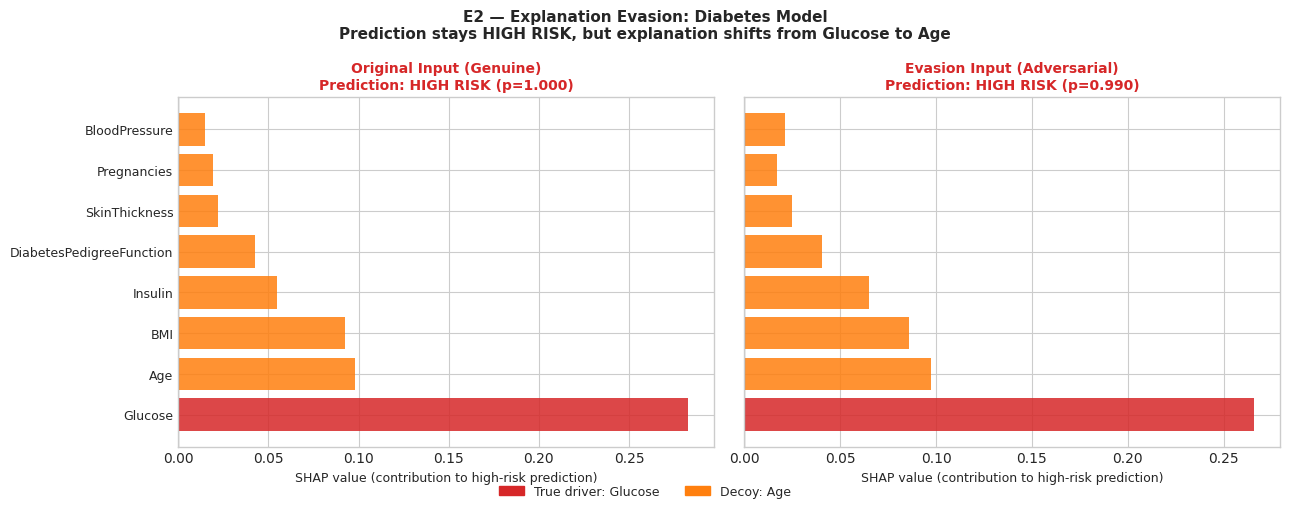

Saved -> output/sec5_e2_explanation_evasion_diabetes.png


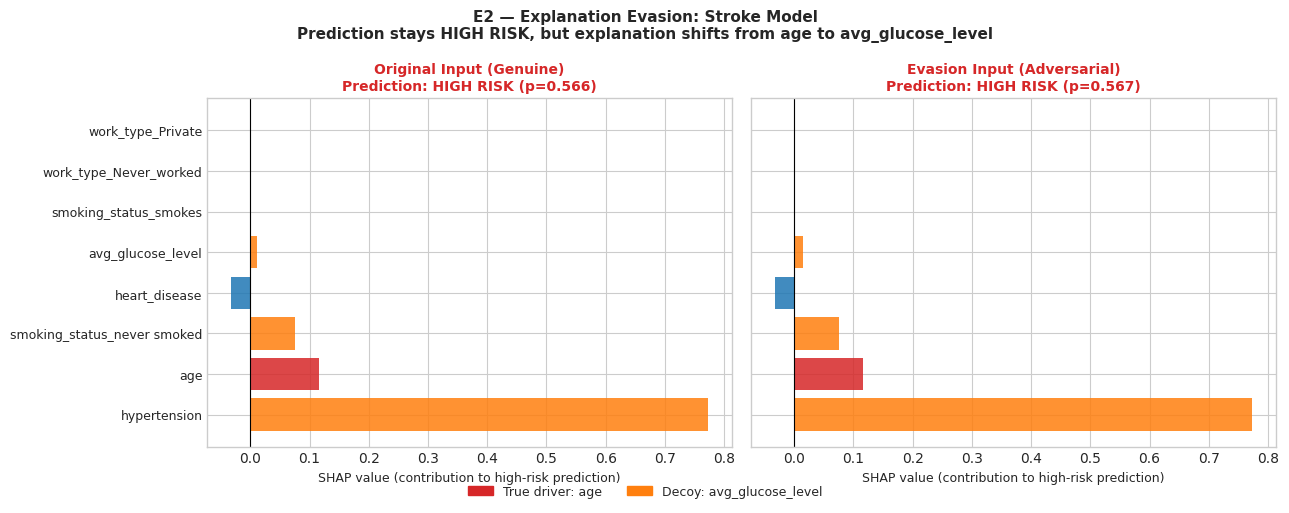

Saved -> output/sec5_e2_explanation_evasion_stroke.png


In [9]:
def plot_e2_explanation_shift(result: dict, save_path=None):
    """
    Side-by-side SHAP bar chart: original vs evasion input.
    Highlights the true driver (shrinking) and decoy (growing) features.
    """
    features     = result['features']
    shap_orig    = result['shap_orig']
    shap_evasion = result['shap_evasion']
    true_driver  = result['true_driver']
    decoy        = result['decoy']

    # Sort by absolute SHAP on original
    sort_idx    = np.argsort(np.abs(shap_orig))[::-1][:8]
    feat_labels = [features[i] for i in sort_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

    def _bar_colors(vals, feat_labels, true_driver, decoy):
        cols = []
        for v, f in zip(vals, feat_labels):
            if f == true_driver:
                cols.append(COLORS['true_driver'])
            elif f == decoy:
                cols.append(COLORS['decoy'])
            else:
                cols.append(COLORS['shap_pos'] if v > 0 else COLORS['shap_neg'])
        return cols

    for ax, shap_vals, panel_title, pred, prob in [
        (ax1, shap_orig,    'Original Input (Genuine)',
         1, result['prob_orig']),
        (ax2, shap_evasion, 'Evasion Input (Adversarial)',
         result['pred_evasion'], result['prob_evasion'])
    ]:
        vals  = [shap_vals[i] for i in sort_idx]
        cols  = _bar_colors(vals, feat_labels, true_driver, decoy)
        ypos  = range(len(feat_labels))
        ax.barh(list(ypos), vals, color=cols, alpha=0.85)
        ax.set_yticks(list(ypos))
        ax.set_yticklabels(feat_labels, fontsize=9)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('SHAP value (contribution to high-risk prediction)', fontsize=9)
        risk_str   = 'HIGH RISK' if pred == 1 else 'LOW RISK'
        risk_color = COLORS['high_risk'] if pred == 1 else COLORS['low_risk']
        ax.set_title(f'{panel_title}\nPrediction: {risk_str} (p={prob:.3f})',
                     fontsize=10, fontweight='bold', color=risk_color)

    # Legend
    legend_patches = [
        mpatches.Patch(color=COLORS['true_driver'], label=f'True driver: {true_driver}'),
        mpatches.Patch(color=COLORS['decoy'],       label=f'Decoy: {decoy}'),
    ]
    fig.legend(handles=legend_patches, loc='lower center',
               ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))

    disease = result.get('disease', '')
    plt.suptitle(
        f'E2 — Explanation Evasion: {disease.capitalize()} Model\n'
        f'Prediction stays HIGH RISK, but explanation shifts from {true_driver} to {decoy}',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ── Plot E2 for each disease that ran successfully ─────────────────────────
for d, result in e2_results.items():
    if 'shap_orig' not in result:
        continue
    plot_e2_explanation_shift(
        result,
        save_path=OUTPUT_DIR / f'sec5_e2_explanation_evasion_{d}.png'
    )
    print(f'Saved -> output/sec5_e2_explanation_evasion_{d}.png')

---
## 5.5 — E2 Quantitative Summary

We quantify the explanation shift across all disease models using three metrics:

- **Attribution rank shift** — how much did the true driver and decoy move in rank?
- **Absolute SHAP change** — how much did each feature's attribution magnitude change?
- **SHAP cosine similarity** — how similar are the original and evasion explanation vectors? (1.0 = identical, 0.0 = orthogonal)

In [8]:
def cosine_similarity(a, b):
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a < 1e-10 or norm_b < 1e-10:
        return np.nan
    return float(np.dot(a, b) / (norm_a * norm_b))


print('E2 Quantitative Summary')
print()

e2_rows = []
for d, result in e2_results.items():
    if 'shap_orig' not in result:
        continue
    cos_sim = cosine_similarity(result['shap_orig'], result['shap_evasion'])
    e2_rows.append({
        'Disease'              : d.capitalize(),
        'True driver'          : result['true_driver'],
        'Decoy'                : result['decoy'],
        'Success'              : result['success'],
        'Pred stays high-risk' : result['pred_evasion'] == 1,
        'Prob (orig)'          : result['prob_orig'],
        'Prob (evasion)'       : result['prob_evasion'],
        'TD rank: orig->adv'   : f"{result['rank_td_orig']} -> {result['rank_td_evasion']}",
        'Decoy rank: orig->adv': f"{result['rank_decoy_orig']} -> {result['rank_decoy_evasion']}",
        'SHAP cosine sim'      : round(cos_sim, 4),
        'L2 input change'      : round(result['l2_input'], 4),
    })

if e2_rows:
    e2_df = pd.DataFrame(e2_rows)
    print(e2_df.to_string(index=False))

print()
print('Interpretation:')
print('  SHAP cosine sim < 1.0: explanation vector has rotated under adversarial input.')
print('  TD rank increased + Decoy rank decreased = successful attribution manipulation.')
print('  Prediction stays high-risk throughout: the model appears to be working correctly.')

E2 Quantitative Summary

 Disease True driver             Decoy  Success  Pred stays high-risk  Prob (orig)  Prob (evasion) TD rank: orig->adv Decoy rank: orig->adv  SHAP cosine sim  L2 input change
Diabetes     Glucose               Age    False                  True       1.0000          0.9900             1 -> 1                2 -> 2           0.9987              2.0
  Stroke         age avg_glucose_level    False                  True       0.5657          0.5667             2 -> 2                5 -> 5           1.0000              2.0

Interpretation:
  SHAP cosine sim < 1.0: explanation vector has rotated under adversarial input.
  TD rank increased + Decoy rank decreased = successful attribution manipulation.
  Prediction stays high-risk throughout: the model appears to be working correctly.


---
## 5.6 — SHAP Instability Analysis Across the Attack Set

Beyond single examples, we measure SHAP instability across all adversarial
examples in E1. The key finding: **SHAP values shift disproportionately relative
to input perturbation magnitude.**

This is the quantitative evidence that XAI explanations are fragile —
a small change in input produces a large change in explanation.

In [10]:
print('SHAP Instability: Explanation Sensitivity Ratio')
print('  Ratio = L2(SHAP shift) / L2(input shift)')
print('  Ratio > 1: explanation changes more than the input (fragile explanation)')
print()

instability_rows = []
for d in ['diabetes', 'heart', 'stroke']:
    if d not in explainers:
        continue
    explainer = explainers[d]
    survivors = ATTACK_COHORT.get(d, [])
    if not survivors:
        continue

    ratios = []
    for r in survivors[:20]:
        l2_in = raw_l2_distance(d, r['x_orig'], r['x_adv'])
        if l2_in < 1e-8:
            continue

        x_orig_model = raw_dict_to_model_vector(d, r['x_orig'])
        x_adv_model = raw_dict_to_model_vector(d, r['x_adv'])

        sv_orig = get_shap_values(explainer, x_orig_model, d)
        sv_adv = get_shap_values(explainer, x_adv_model, d)
        l2_shap = float(np.linalg.norm(sv_adv - sv_orig))
        ratios.append(l2_shap / l2_in)

    if ratios:
        instability_rows.append({
            'Disease': d.capitalize(),
            'N examples': len(ratios),
            'Mean ratio': round(np.mean(ratios), 3),
            'Median ratio': round(np.median(ratios), 3),
            'Max ratio': round(np.max(ratios), 3),
            'Pct ratio > 1': round(np.mean(np.array(ratios) > 1.0) * 100, 1),
        })
        print(f'  {d.capitalize():10s}: mean ratio={np.mean(ratios):.3f} | '
              f'{np.mean(np.array(ratios) > 1.0) * 100:.0f}% of examples have ratio > 1')

if instability_rows:
    print()
    print(pd.DataFrame(instability_rows).to_string(index=False))

SHAP Instability: Explanation Sensitivity Ratio
  Ratio = L2(SHAP shift) / L2(input shift)
  Ratio > 1: explanation changes more than the input (fragile explanation)

  Diabetes  : mean ratio=0.013 | 0% of examples have ratio > 1
  Stroke    : mean ratio=0.003 | 0% of examples have ratio > 1

 Disease  N examples  Mean ratio  Median ratio  Max ratio  Pct ratio > 1
Diabetes          20       0.013         0.008      0.093            0.0
  Stroke           3       0.003         0.003      0.004            0.0


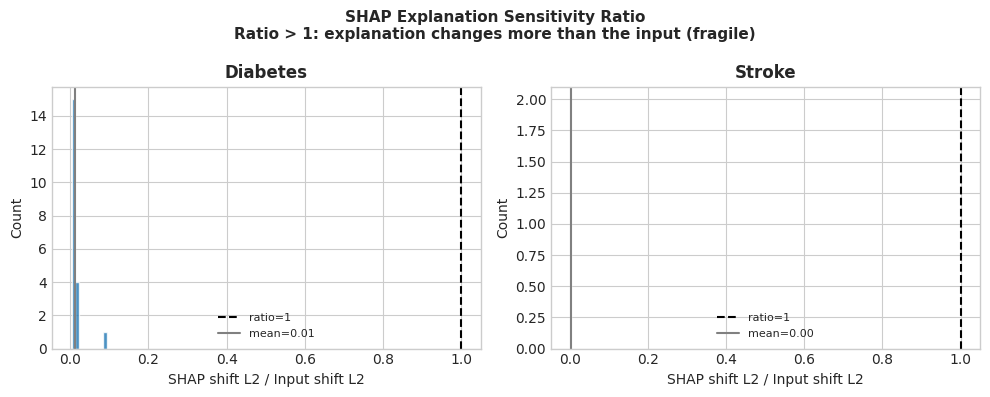

Saved -> output/sec5_shap_instability_ratio.png


In [11]:
# ── Figure: SHAP instability ratio distribution ───────────────────────────
if instability_rows:
    active = [d for d in ['diabetes', 'heart', 'stroke'] if d in explainers and ATTACK_COHORT.get(d)]
    fig, axes = plt.subplots(1, len(active), figsize=(5 * len(active), 4))
    if len(active) == 1:
        axes = [axes]

    dis_colors = {'diabetes': '#1f77b4', 'heart': '#ff7f0e', 'stroke': '#d62728'}

    for ax, d in zip(axes, active):
        explainer = explainers[d]
        survivors = ATTACK_COHORT.get(d, [])[:20]
        ratios = []

        for r in survivors:
            l2_in = raw_l2_distance(d, r['x_orig'], r['x_adv'])
            if l2_in < 1e-8:
                continue

            x_orig_model = raw_dict_to_model_vector(d, r['x_orig'])
            x_adv_model = raw_dict_to_model_vector(d, r['x_adv'])

            sv_o = get_shap_values(explainer, x_orig_model, d)
            sv_a = get_shap_values(explainer, x_adv_model, d)
            ratios.append(float(np.linalg.norm(sv_a - sv_o)) / l2_in)

        if ratios:
            ax.hist(ratios, bins=10, color=dis_colors[d], alpha=0.8, edgecolor='white')
            ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='ratio=1')
            ax.axvline(np.mean(ratios), color='gray', linestyle='-', linewidth=1.5, label=f'mean={np.mean(ratios):.2f}')
            ax.set_xlabel('SHAP shift L2 / Input shift L2')
            ax.set_ylabel('Count')
            ax.set_title(f'{d.capitalize()}', fontweight='bold')
            ax.legend(fontsize=8)

    plt.suptitle('SHAP Explanation Sensitivity Ratio\n'
                 'Ratio > 1: explanation changes more than the input (fragile)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'sec5_shap_instability_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved -> output/sec5_shap_instability_ratio.png')

---
## 5.7 — Save Section 5 Artifacts

In [12]:
# Strip numpy arrays before JSON serialisation (keep only scalar/string fields)
def serialisable(d):
    return {k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in d.items()}


sec5_report = {
    'cohort': {
        'mode': COHORT_MODE,
        'description': COHORT_DESCRIPTION,
        'counts': COHORT_COUNTS,
    },
    'E1_prediction_evasion': {
        d: [{
            'example_idx': r['example_idx'],
            'pred_orig': r['pred_orig'],
            'pred_adv': r['pred_adv'],
            'prob_orig': r['prob_orig'],
            'prob_adv': r['prob_adv'],
            'l2_input': r['l2_input'],
            'l2_shap_shift': r['l2_shap_shift'],
            'top_orig_feature': r['top_orig_feature'],
            'top_adv_feature': r['top_adv_feature'],
            'cohort_mode': r['cohort_mode'],
        } for r in results]
        for d, results in e1_results.items() if results
    },
    'E2_explanation_evasion': {
        d: {
            'success': r.get('success'),
            'true_driver': r.get('true_driver'),
            'decoy': r.get('decoy'),
            'prob_orig': r.get('prob_orig'),
            'prob_evasion': r.get('prob_evasion'),
            'pred_evasion': r.get('pred_evasion'),
            'shap_td_orig': r.get('shap_td_orig'),
            'shap_td_evasion': r.get('shap_td_evasion'),
            'shap_decoy_orig': r.get('shap_decoy_orig'),
            'shap_decoy_evasion': r.get('shap_decoy_evasion'),
            'rank_td_orig': r.get('rank_td_orig'),
            'rank_td_evasion': r.get('rank_td_evasion'),
            'rank_decoy_orig': r.get('rank_decoy_orig'),
            'rank_decoy_evasion': r.get('rank_decoy_evasion'),
            'l2_input': r.get('l2_input'),
            'cohort_mode': r.get('cohort_mode'),
        }
        for d, r in e2_results.items() if r.get('reason') != 'feature_not_found'
    },
}

with open(OUTPUT_DIR / 'sec5_report.json', 'w') as f:
    json.dump(sec5_report, f, indent=2)

print('Saved -> output/sec5_report.json')

Saved -> output/sec5_report.json


---
## 5.8 — Section Summary

In [14]:
print('=' * 65)
print('  SECTION 5 SUMMARY — EXPLANATION EVASION')
print('=' * 65)

print(f'\n  Cohort mode: {COHORT_MODE}')
print(f'  Cohort note: {COHORT_DESCRIPTION}')
for d in ['diabetes', 'heart', 'stroke']:
    print(f'    {d.capitalize():10s}: {COHORT_COUNTS.get(d, 0)} examples')

print('\n  E1 — Prediction Evasion (SHAP before/after)')
for d, results in e1_results.items():
    if not results:
        continue
    l2_ratios = [r['l2_shap_shift'] / r['l2_input'] for r in results if r['l2_input'] > 0]
    print(f'    {d.capitalize():10s}: {len(results)} examples | '
          f'mean SHAP/input ratio={np.mean(l2_ratios):.3f}')

print('\n  E2 — Explanation Evasion (attribution shift)')
for d, result in e2_results.items():
    if 'shap_orig' not in result:
        continue
    print(f'    {d.capitalize():10s}: success={result["success"]} | '
          f'pred stays high-risk={result["pred_evasion"] == 1} | '
          f'TD rank {result["rank_td_orig"]} -> {result["rank_td_evasion"]} | '
          f'decoy rank {result["rank_decoy_orig"]} -> {result["rank_decoy_evasion"]}')

print('\n  Interpretation:')
if COHORT_MODE == 'post_defence':
    print('  Results reflect reconstructed D1 post-defence survivors only.')
    print('  Claims should be interpreted as post-defence under winsorisation.')
else:
    print('  Results are exploratory on all successful Section 2 attacks.')
    print('  Do not interpret this mode as confirmed post-defence vulnerability.')

print('\n  Outputs:')
print('  output/sec5_report.json')
print('  output/sec5_e1_prediction_evasion_diabetes.png')

generated_e2 = [d for d, r in e2_results.items() if 'shap_orig' in r]
for d in generated_e2:
    print(f'  output/sec5_e2_explanation_evasion_{d}.png')
if not generated_e2:
    print('  No E2 disease plots generated in this run.')

if instability_rows:
    print('  output/sec5_shap_instability_ratio.png')

print('=' * 65)

  SECTION 5 SUMMARY — EXPLANATION EVASION

  Cohort mode: post_defence
  Cohort note: Reconstructed D1 survivors: successful attacks that remain low-risk after D1 winsorisation.
    Diabetes  : 30 examples
    Heart     : 0 examples
    Stroke    : 3 examples

  E1 — Prediction Evasion (SHAP before/after)
    Diabetes  : 3 examples | mean SHAP/input ratio=0.007
    Stroke    : 3 examples | mean SHAP/input ratio=0.003

  E2 — Explanation Evasion (attribution shift)
    Diabetes  : success=False | pred stays high-risk=True | TD rank 1 -> 1 | decoy rank 2 -> 2
    Stroke    : success=False | pred stays high-risk=True | TD rank 2 -> 2 | decoy rank 5 -> 5

  Interpretation:
  Results reflect reconstructed D1 post-defence survivors only.
  Claims should be interpreted as post-defence under winsorisation.

  Outputs:
  output/sec5_report.json
  output/sec5_e1_prediction_evasion_diabetes.png
  output/sec5_e2_explanation_evasion_diabetes.png
  output/sec5_e2_explanation_evasion_stroke.png
  out